# 벡터DB 이미지 검색 시각화

design_chatbot의 이미지 검색 파이프라인(CLIP + ChromaDB)을 실행하고,
검색 결과를 시각적으로 확인하는 노트북입니다.

## 1. 환경 설정

In [ ]:
import os
import chromadb
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib

from utils import (
    get_image_embedding,
    get_text_embedding,
    design_id_to_local_image,
    search_and_filter_similar_designs,
)

from dotenv import load_dotenv
load_dotenv()

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ChromaDB 로드
chroma_client = chromadb.PersistentClient(path="C:\\Users\\playdata2\\Desktop\\SKN_AI_20\\SKN20-FINAL-2TEAM\\design\\chroma_db")
print(f"사용 가능한 컬렉션: {[c.name for c in chroma_client.list_collections()]}")
image_collection = chroma_client.get_collection(name="design")

IMAGE_DIR = os.path.join("..", "data", "images_2")

print(f"ChromaDB: {image_collection.count()}개 디자인")
print(f"이미지 디렉토리: {os.path.abspath(IMAGE_DIR)}")

사용 가능한 컬렉션: ['design']
ChromaDB: 21801개 디자인
이미지 디렉토리: c:\Users\playdata2\Desktop\SKN_AI_20\SKN20-FINAL-2TEAM\design\data\images


## 2. 시각화 함수 정의

In [3]:
def visualize_search_results(query_image_path, n_results=10):
    """
    쿼리 이미지로 벡터DB 검색 후 결과를 시각화합니다.

    Args:
        query_image_path: 검색할 이미지 경로
        n_results: 검색 결과 개수 (기본 10개)
    """
    # 1) CLIP 임베딩 생성
    print(f"[1/3] CLIP 임베딩 생성 중... ({os.path.basename(query_image_path)})")
    embedding = get_image_embedding(query_image_path)
    if embedding is None:
        print("임베딩 생성 실패!")
        return None

    # 2) 벡터DB 검색 (출원번호 중복 필터링 포함)
    print(f"[2/3] 벡터DB 검색 중... (상위 {n_results}개)")
    results = search_and_filter_similar_designs(image_collection, embedding, n_results=n_results)

    n_found = len(results['ids'][0])
    print(f"[3/3] {n_found}개 유사 디자인 발견!")

    # 3) 결과 정리
    search_data = []
    for i in range(n_found):
        design_id = results['ids'][0][i]
        metadata = results['metadatas'][0][i]
        distance = results['distances'][0][i]
        local_path = design_id_to_local_image(design_id)

        search_data.append({
            'rank': i + 1,
            'design_id': design_id,
            'distance': distance,
            'app_number': metadata.get('applicationNumber', 'N/A'),
            'article_name': metadata.get('articleName', 'N/A'),
            'admst_stat': metadata.get('admstStat', 'N/A'),
            'image_path': local_path,
        })

    # 4) 시각화: 쿼리 1개 + 결과 N개, 한 행에 6개씩
    cols = 6
    total_items = n_found + 1  # 쿼리 포함
    rows = (total_items + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 5))
    if rows == 1:
        axes = axes.reshape(1, -1)

    # 모든 축 숨기기
    for r in range(rows):
        for c in range(cols):
            axes[r][c].axis("off")

    # 쿼리 이미지 (0번 위치)
    ax_query = axes[0][0]
    try:
        ax_query.imshow(Image.open(query_image_path))
    except Exception:
        ax_query.text(0.5, 0.5, "로드 실패", ha="center", va="center", fontsize=12)
    ax_query.set_title(
        f"[QUERY]\n{os.path.basename(query_image_path)}",
        fontsize=8, color="blue", fontweight="bold"
    )

    # 검색 결과 이미지 (1번 위치부터)
    for idx, item in enumerate(search_data):
        pos = idx + 1
        row = pos // cols
        col = pos % cols
        ax = axes[row][col]

        if item['image_path'] and os.path.exists(item['image_path']):
            try:
                ax.imshow(Image.open(item['image_path']))
            except Exception:
                ax.text(0.5, 0.5, "로드 실패", ha="center", va="center", fontsize=10)
        else:
            ax.text(0.5, 0.5, "이미지 없음", ha="center", va="center", fontsize=10)

        # 거리에 따른 색상 (가까울수록 녹색)
        color = 'green' if item['distance'] < 0.05 else ('orange' if item['distance'] < 0.08 else 'red')

        ax.set_title(
            f"Top-{item['rank']}  dist={item['distance']:.4f}\n"
            f"{item['article_name']}\n"
            f"출원: {item['app_number']}\n({item['admst_stat']})",
            fontsize=7, color=color
        )

    fig.suptitle(
        f"벡터DB 이미지 검색 결과 (상위 {n_found}개, 출원번호 중복 필터 적용)",
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()

    # 텍스트 요약 테이블
    print("\n" + "=" * 80)
    header = f"{'순위':>4} | {'거리':>8} | {'상품명':<25} | {'출원번호':<18} | {'상태'}"
    print(header)
    print("-" * 80)
    for item in search_data:
        print(f"{item['rank']:>4} | {item['distance']:>8.4f} | {item['article_name']:<25} | {item['app_number']:<18} | {item['admst_stat']}")
    print("=" * 80)

    return search_data


In [4]:
def visualize_text_search(query_text, n_results=10):
    """
    텍스트 쿼리로 벡터DB 검색 후 결과를 시각화합니다.
    (CLIP 텍스트 임베딩 -> 이미지 검색)
    """
    print(f"[1/3] 텍스트 임베딩 생성 중... ('{query_text}')")
    embedding, translated = get_text_embedding(query_text, translate_korean=True)
    if embedding is None:
        print("임베딩 생성 실패!")
        return None

    print(f"[2/3] 벡터DB 검색 중... (번역: '{translated}')")
    results = search_and_filter_similar_designs(image_collection, embedding, n_results=n_results)

    n_found = len(results['ids'][0])
    print(f"[3/3] {n_found}개 유사 디자인 발견!")

    search_data = []
    for i in range(n_found):
        design_id = results['ids'][0][i]
        metadata = results['metadatas'][0][i]
        distance = results['distances'][0][i]
        local_path = design_id_to_local_image(design_id)
        search_data.append({
            'rank': i + 1, 'design_id': design_id, 'distance': distance,
            'app_number': metadata.get('applicationNumber', 'N/A'),
            'article_name': metadata.get('articleName', 'N/A'),
            'admst_stat': metadata.get('admstStat', 'N/A'),
            'image_path': local_path,
        })

    cols = 6
    total_items = n_found + 1
    rows = (total_items + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 5))
    if rows == 1:
        axes = axes.reshape(1, -1)
    for r in range(rows):
        for c in range(cols):
            axes[r][c].axis("off")

    # 쿼리 텍스트 표시
    ax_query = axes[0][0]
    ax_query.text(
        0.5, 0.5,
        f"[TEXT QUERY]\n\n\"{query_text}\"\n\n(translated:\n\"{translated}\")",
        ha="center", va="center", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8),
        transform=ax_query.transAxes, wrap=True
    )
    ax_query.set_title("[QUERY]", fontsize=9, color="blue", fontweight="bold")

    for idx, item in enumerate(search_data):
        pos = idx + 1
        row = pos // cols
        col = pos % cols
        ax = axes[row][col]
        if item['image_path'] and os.path.exists(item['image_path']):
            try:
                ax.imshow(Image.open(item['image_path']))
            except Exception:
                ax.text(0.5, 0.5, "로드 실패", ha="center", va="center", fontsize=10)
        else:
            ax.text(0.5, 0.5, "이미지 없음", ha="center", va="center", fontsize=10)
        color = 'green' if item['distance'] < 0.05 else ('orange' if item['distance'] < 0.08 else 'red')
        ax.set_title(
            f"Top-{item['rank']}  dist={item['distance']:.4f}\n"
            f"{item['article_name']}\n"
            f"출원: {item['app_number']}\n({item['admst_stat']})",
            fontsize=7, color=color
        )

    fig.suptitle(
        f"텍스트 검색 결과: \"{query_text}\" (상위 {n_found}개)",
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 80)
    header = f"{'순위':>4} | {'거리':>8} | {'상품명':<25} | {'출원번호':<18} | {'상태'}"
    print(header)
    print("-" * 80)
    for item in search_data:
        print(f"{item['rank']:>4} | {item['distance']:>8.4f} | {item['article_name']:<25} | {item['app_number']:<18} | {item['admst_stat']}")
    print("=" * 80)
    return search_data


## 3. 이미지 검색 테스트

쿼리 이미지 경로를 본인 환경에 맞게 수정하세요.

[1/3] CLIP 임베딩 생성 중... (3020090053503-api_xml-0_000.jpg)
[2/3] 벡터DB 검색 중... (상위 10개)
[3/3] 8개 유사 디자인 발견!


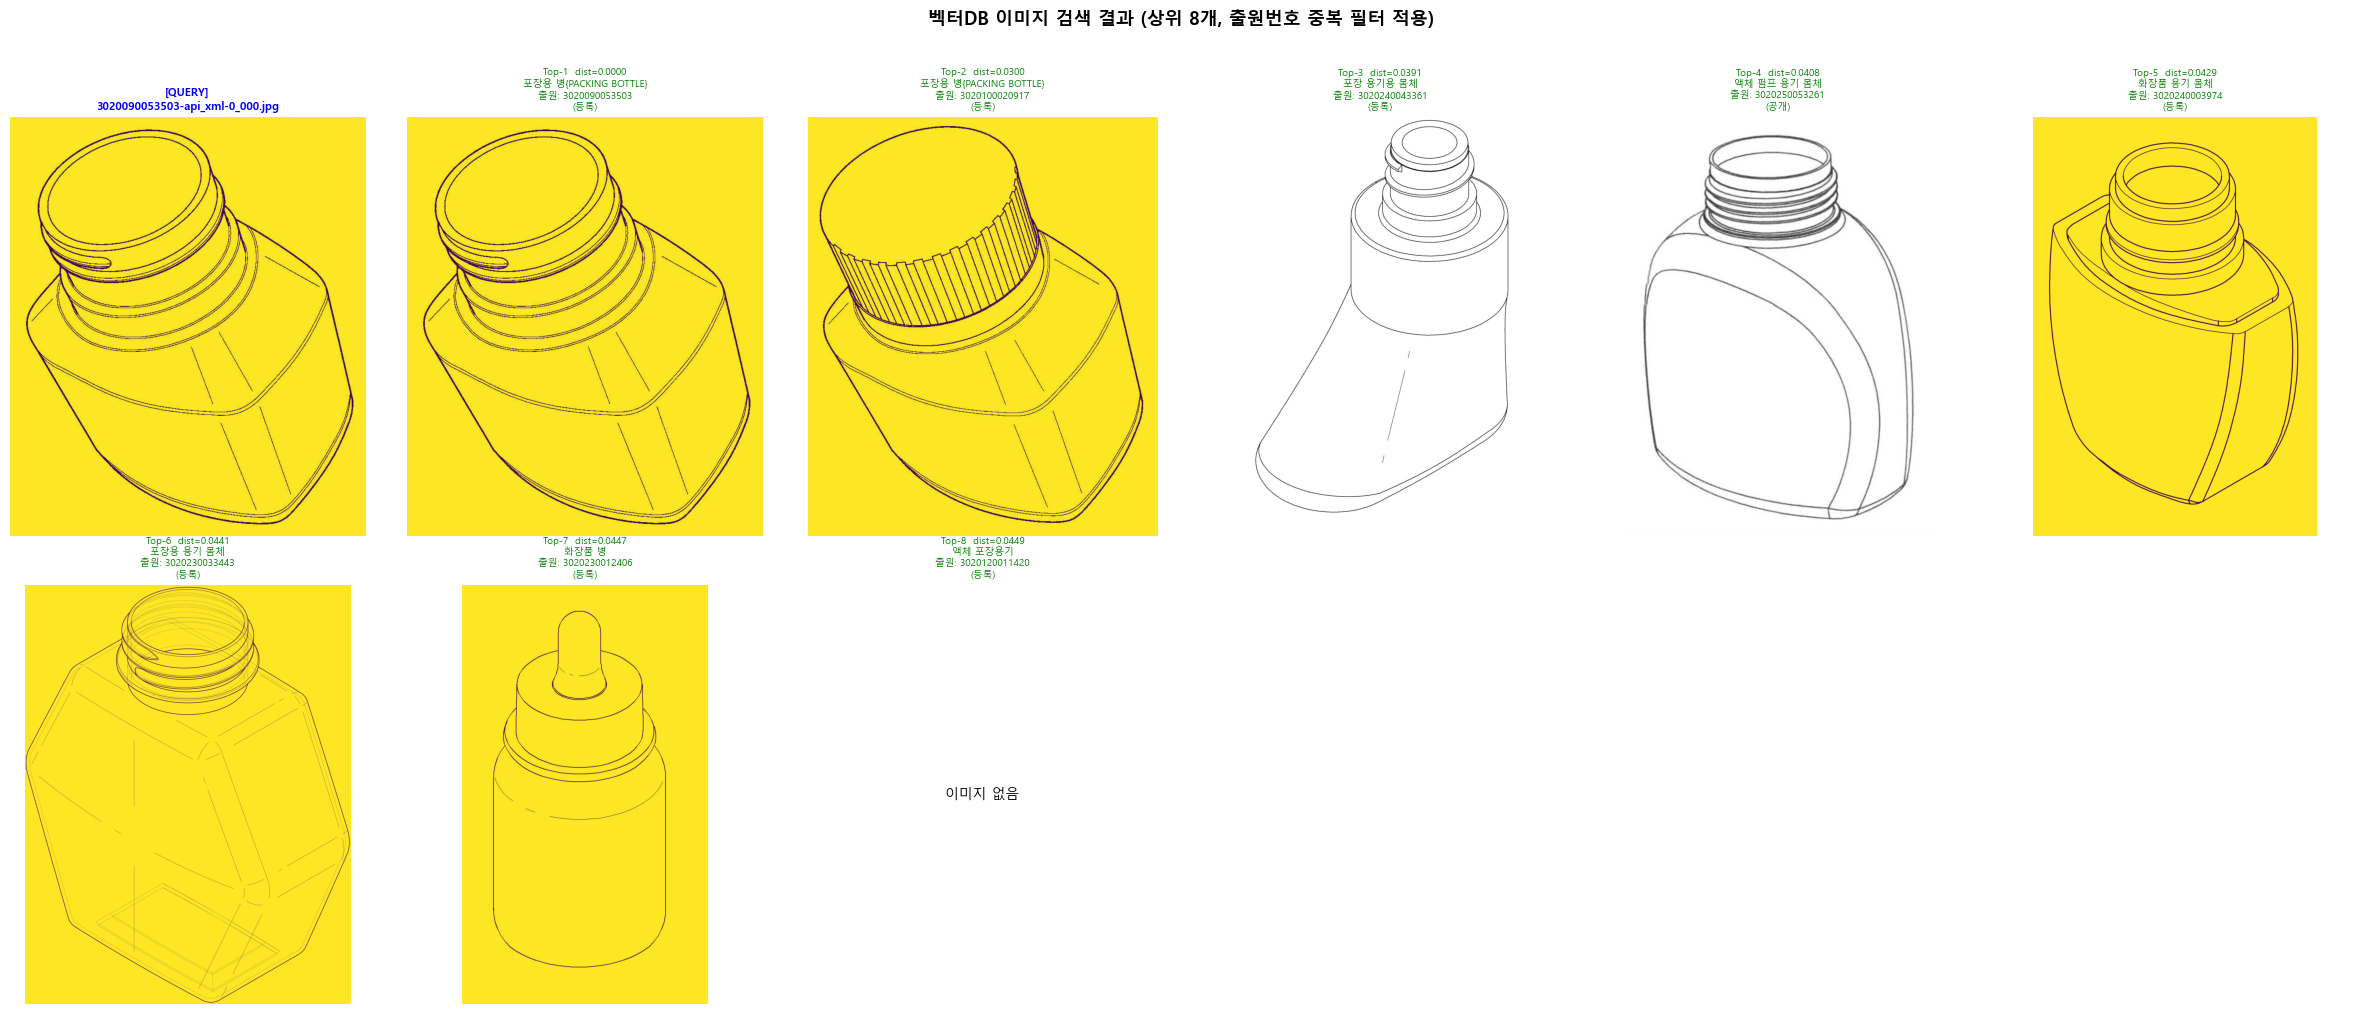


  순위 |       거리 | 상품명                       | 출원번호               | 상태
--------------------------------------------------------------------------------
   1 |   0.0000 | 포장용 병{PACKING BOTTLE}     | 3020090053503      | 등록
   2 |   0.0300 | 포장용 병{PACKING BOTTLE}     | 3020100020917      | 등록
   3 |   0.0391 | 포장 용기용 몸체                 | 3020240043361      | 등록
   4 |   0.0408 | 액체 펌프 용기 몸체               | 3020250053261      | 공개
   5 |   0.0429 | 화장품 용기 몸체                 | 3020240003974      | 등록
   6 |   0.0441 | 포장용 용기 몸체                 | 3020230033443      | 등록
   7 |   0.0447 | 화장품 병                     | 3020230012406      | 등록
   8 |   0.0449 | 액체 포장용기                   | 3020120011420      | 등록


In [7]:
# 이미지 경로를 본인 환경에 맞게 수정하세요
query_image = r"C:\Users\playdata2\Desktop\SKN_AI_20\SKN20-FINAL-2TEAM\design\data\images\3020090053503-api_xml-0_000.jpg"

results = visualize_search_results(query_image, n_results=10)

## 4. 텍스트 검색 테스트

텍스트로 유사 디자인을 검색합니다. (CLIP 텍스트 임베딩 -> 이미지 검색)

In [9]:
results_text = visualize_text_search("펌프형 용기", n_results=10)

[1/3] 텍스트 임베딩 생성 중... ('펌프형 용기')
   한글 감지: '펌프형 용기' → 영어로 번역 중...
텍스트 임베딩 생성 실패: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}
임베딩 생성 실패!


## 5. 여러 쿼리 이미지 비교

In [12]:
# 여러 쿼리 이미지 경로 (본인 환경에 맞게 수정)
query_images = [
    r"C:\Users\playdata2\Desktop\SKN_AI_20\SKN20-FINAL-2TEAM\design\data\images(21,895개)\3019810003379-api_xml-1_001.JPG",
    # 추가 이미지 경로를 여기에 넣으세요
    # r"경로\다른이미지.JPG",
]

for img_path in query_images:
    if os.path.exists(img_path):
        print(f"\n{\"=\" * 70}")
        print(f"쿼리: {os.path.basename(img_path)}")
        print(f"{\"=\" * 70}")
        visualize_search_results(img_path, n_results=10)
    else:
        print(f"파일 없음: {img_path}")

SyntaxError: f-string expression part cannot include a backslash (3427311364.py, line 10)